In [230]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import re, string, unicodedata # type: ignore
import warnings # type: ignore
warnings.filterwarnings('ignore')

import seaborn as sns # type: ignore
import matplotlib.pyplot as plt # type: ignore
import plotly.express as px # type: ignore

import nltk # type: ignore
from nltk.stem import WordNetLemmatizer # type: ignore
from nltk.tokenize import word_tokenize # type: ignore
from nltk.corpus import wordnet # type: ignore
from nltk.corpus import stopwords # type: ignore
from nltk.sentiment.vader import SentimentIntensityAnalyzer # type: ignore

from sklearn.feature_extraction.text import CountVectorizer # type: ignore
from wordcloud import WordCloud, STOPWORDS # type: ignore
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
from string import punctuation # type: ignore

In [231]:
%%time

#Loading the dataset
df = pd.read_csv('/Users/treva.ogwang/Desktop/Codes/social_media/sentimentdataset.csv')

CPU times: user 4.13 ms, sys: 1.66 ms, total: 5.79 ms
Wall time: 4.22 ms


In [232]:
#Displaying first 5 rows of the dataset
df.head() 

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [233]:
df['Sentiment'].value_counts()

Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Contentment        14
                   ..
Adrenaline          1
Harmony             1
ArtisticBurst       1
Radiance            1
Elegance            1
Name: count, Length: 279, dtype: int64

Exploratory Data Analysis

In [234]:
#Checking the structure of the datset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [235]:
#Getting the shape of the dataset (rows, columns)
df.shape

(732, 15)

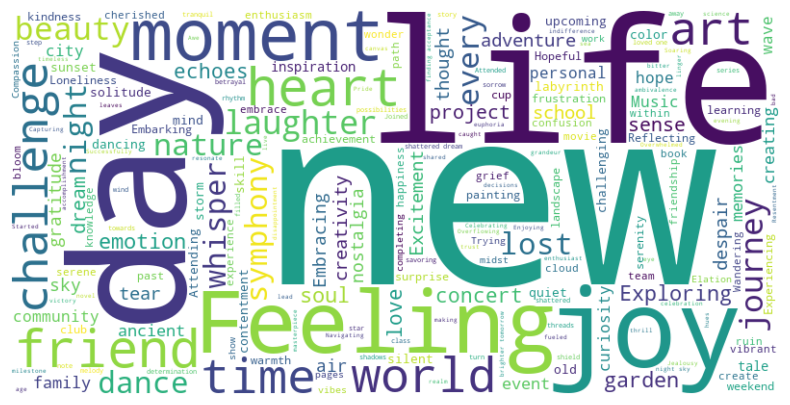

In [236]:
#Word Cloud in the 'Text' column
#Combining all text data into one large string
text_data = " ".join(df['Text'].dropna())  # Drop NaN values if any

#Generating the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

#Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axis
plt.show()

Data Cleaning

In [237]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [238]:
#Checking for duplicates in the 'Text' column
df['Text'].duplicated().sum()

np.int64(25)

In [239]:
#Dropping the duplicates in the 'Text' column
df = df.drop_duplicates(subset='Text', keep='first')
print("Duplicates dropped")

Duplicates dropped


In [240]:
#Dropping unnecessary columns
df = df.drop(['Unnamed: 0.1', 'Unnamed: 0', 'Timestamp', 'Year', 'Month', 'Day', 'Hour'], axis=1)

In [241]:
df.shape

(707, 8)

In [242]:
#Checking missing value
df.isnull().sum()

Text         0
Sentiment    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
dtype: int64

In [243]:
#Adding the Length column that gets the number of tokens in each row in the 'Text' column
df['Length'] = df['Text'].apply(lambda x: len(str(x).split()))

#Putting the 'Length' column to be the second column of the dataset
df.insert(1, 'Length', df.pop('Length'))

df.head()

,Text,Length,Sentiment,User,Platform,Hashtags,Retweets,Likes,Country
0,Enjoying a beautiful day at the park! ...,7,Positive,User123,Twitter,#Nature #Park,15.0,30.0,USA
1,Traffic was terrible this morning. ...,5,Negative,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,Just finished an amazing workout! 💪 ...,6,Positive,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA
3,Excited about the upcoming weekend getaway! ...,6,Positive,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK
4,Trying out a new recipe for dinner tonight. ...,8,Neutral,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia


Data Preprocessing

In [244]:
#Checking missing value
df.isnull().sum()

Text         0
Length       0
Sentiment    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
dtype: int64

4. Data Cleaning

In [245]:
#Downloading the stopwords from nltk
nltk.download("stopwords")

#List of stop words 
stop_words = set(stopwords.words('english'))

#Displaying the stop words
print(stop_words)

{'as', 'he', "didn't", 'our', 'ain', 'weren', 'at', 'with', 't', 'ours', 'above', 'couldn', 'you', 'against', 'or', 'll', 'being', 'i', 'hers', 'too', 'than', "shouldn't", 'nor', 'just', 'do', 'a', 'my', 'what', "wouldn't", 'those', 'didn', 'below', 'themselves', 'yourself', 'only', 'by', "won't", "it's", 'were', "she's", 'while', 'which', 'mustn', 'does', 'then', 'the', 'who', 'all', 'don', 'that', 'such', 'theirs', "hasn't", 'more', "shan't", 'wasn', 'himself', 've', 'into', 'why', 'same', 'off', 'from', "that'll", 'during', "should've", 'haven', "isn't", 'if', 'had', "mightn't", 'both', 'no', "weren't", 'am', 'but', 'through', 'be', 'of', 'this', 'when', 'own', 'aren', 'm', "needn't", 'these', 'have', 'its', 'it', 'under', "hadn't", 'on', 'd', 'about', 'won', 'will', 'is', 'we', 'up', 'most', 'shan', 'she', 'few', "you'd", 'not', "you've", 'your', 'further', "you're", 'once', 'between', "you'll", 'very', 's', 'should', 'needn', "aren't", 'herself', 'here', 'me', 'o', 'again', 'hadn'

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [246]:
#Creating a function to clean the dataset.

def clean_text(text):
    text = text.lower() #Convert text to lower-case
    text = re.sub(r'http\S+|www.\S+', '', text) #Removing URL
    text = re.sub(r'\d+', '', text) #Removing digits
    text = text.translate(str.maketrans('', '', string.punctuation)) #Removing punctuation
    text = text.strip() #Removing white spaces
    text = re.sub(r'@\S+', '', text) # Remove mentions (e.g., @username)
    text = re.sub(r'#\S+', '', text) # Remove hashtags (e.g., #hashtag)
    text = re.sub(r'[^a-z\s]', '', text)     # Remove non-alphabetic characters (punctuation and numbers)
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # Remove non-ASCII characters (including emojis)
    
    text = text.split() #Splitting the text
    text = [word for word in text if word not in stop_words] #Removing stop words
    text = ' '.join(text) #Joining the text
    
    return text

#Applying the function to the dataset and storing it in a new column named 'Cleaned_Text'
df['Cleaned_Text'] = df['Text'].astype(str).apply(clean_text)

#Putting the 'Cleaned_Text' column to be the fifth column of the dataset
df.insert(4, 'Cleaned_Text', df.pop('Cleaned_Text'))

df.head(10)

,Text,Length,Sentiment,User,Cleaned_Text,Platform,Hashtags,Retweets,Likes,Country
0,Enjoying a beautiful day at the park! ...,7,Positive,User123,enjoying beautiful day park,Twitter,#Nature #Park,15.0,30.0,USA
1,Traffic was terrible this morning. ...,5,Negative,CommuterX,traffic terrible morning,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,Just finished an amazing workout! 💪 ...,6,Positive,FitnessFan,finished amazing workout,Instagram,#Fitness #Workout,20.0,40.0,USA
3,Excited about the upcoming weekend getaway! ...,6,Positive,AdventureX,excited upcoming weekend getaway,Facebook,#Travel #Adventure,8.0,15.0,UK
4,Trying out a new recipe for dinner tonight. ...,8,Neutral,ChefCook,trying new recipe dinner tonight,Instagram,#Cooking #Food,12.0,25.0,Australia
5,Feeling grateful for the little things in lif...,8,Positive,GratitudeNow,feeling grateful little things life,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India
6,Rainy days call for cozy blankets and hot coc...,9,Positive,RainyDays,rainy days call cozy blankets hot cocoa,Facebook,#RainyDays #Cozy,10.0,20.0,Canada
7,The new movie release is a must-watch! ...,7,Positive,MovieBuff,new movie release mustwatch,Instagram,#MovieNight #MustWatch,15.0,30.0,USA
8,Political discussions heating up on the timel...,7,Negative,DebateTalk,political discussions heating timeline,Twitter,#Politics #Debate,30.0,60.0,USA
9,Missing summer vibes and beach days. ...,6,Neutral,BeachLover,missing summer vibes beach days,Facebook,#Summer #BeachDays,18.0,35.0,Australia


In [247]:
#Downloading the wordnet from nltk to help with the lematization.

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [248]:
df_cleaned = df.copy()

lemmatizer = WordNetLemmatizer()

# Function to get the correct POS tag for lemmatization
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ  # Adjective
    elif tag.startswith('V'):
        return wordnet.VERB  # Verb
    elif tag.startswith('N'):
        return wordnet.NOUN  # Noun
    elif tag.startswith('R'):
        return wordnet.ADV  # Adverb
    else:
        return wordnet.NOUN  # Default to NOUN if unknown

# Function to lemmatize text with the correct POS tagging
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)  # Tokenize the text
    tagged_tokens = nltk.pos_tag(tokens)  # Get POS tags for tokens
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged_tokens]  # Lemmatize each word with the correct POS tag
    return " ".join(lemmatized_words)

# Apply to your dataset
df_cleaned['Lemmatized_Text'] = df['Cleaned_Text'].apply(lemmatize_text)

In [249]:
#Putting the 'Lemmatized_Text' column to be the sixth column of the dataset
df_cleaned.insert(5, 'Lemmatized_Text', df_cleaned.pop('Lemmatized_Text'))

df_cleaned

,Text,Length,Sentiment,User,Cleaned_Text,Lemmatized_Text,Platform,Hashtags,Retweets,Likes,Country
0,Enjoying a beautiful day at the park! ...,7,Positive,User123,enjoying beautiful day park,enjoy beautiful day park,Twitter,#Nature #Park,15.0,30.0,USA
1,Traffic was terrible this morning. ...,5,Negative,CommuterX,traffic terrible morning,traffic terrible morning,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,Just finished an amazing workout! 💪 ...,6,Positive,FitnessFan,finished amazing workout,finish amaze workout,Instagram,#Fitness #Workout,20.0,40.0,USA
3,Excited about the upcoming weekend getaway! ...,6,Positive,AdventureX,excited upcoming weekend getaway,excited upcoming weekend getaway,Facebook,#Travel #Adventure,8.0,15.0,UK
4,Trying out a new recipe for dinner tonight. ...,8,Neutral,ChefCook,trying new recipe dinner tonight,try new recipe dinner tonight,Instagram,#Cooking #Food,12.0,25.0,Australia
...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,16,Happy,ScienceProjectSuccessHighSchool,collaborating science project received recogni...,collaborate science project receive recognitio...,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK
728,Attending a surprise birthday party organized ...,15,Happy,BirthdayPartyJoyHighSchool,attending surprise birthday party organized fr...,attend surprise birthday party organize friend...,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA
729,Successfully fundraising for a school charity ...,15,Happy,CharityFundraisingTriumphHighSchool,successfully fundraising school charity initia...,successfully fundraise school charity initiati...,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada
730,"Participating in a multicultural festival, cel...",13,Happy,MulticulturalFestivalJoyHighSchool,participating multicultural festival celebrati...,participate multicultural festival celebrate d...,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK


In [250]:
#Creating a new column to get the number of strings for the 'Lemmatized_Text' column
df_cleaned['Length_Lemmatized_Text'] = df_cleaned['Lemmatized_Text'].apply(lambda x: len(str(x).split()))

#Putting the 'Length_Lemmatized_Text' column to be the seventh column of the dataset
df_cleaned.insert(6, 'Length_Lemmatized_Text', df_cleaned.pop('Length_Lemmatized_Text'))

df_cleaned

,Text,Length,Sentiment,User,Cleaned_Text,Lemmatized_Text,Length_Lemmatized_Text,Platform,Hashtags,Retweets,Likes,Country
0,Enjoying a beautiful day at the park! ...,7,Positive,User123,enjoying beautiful day park,enjoy beautiful day park,4,Twitter,#Nature #Park,15.0,30.0,USA
1,Traffic was terrible this morning. ...,5,Negative,CommuterX,traffic terrible morning,traffic terrible morning,3,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,Just finished an amazing workout! 💪 ...,6,Positive,FitnessFan,finished amazing workout,finish amaze workout,3,Instagram,#Fitness #Workout,20.0,40.0,USA
3,Excited about the upcoming weekend getaway! ...,6,Positive,AdventureX,excited upcoming weekend getaway,excited upcoming weekend getaway,4,Facebook,#Travel #Adventure,8.0,15.0,UK
4,Trying out a new recipe for dinner tonight. ...,8,Neutral,ChefCook,trying new recipe dinner tonight,try new recipe dinner tonight,5,Instagram,#Cooking #Food,12.0,25.0,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,16,Happy,ScienceProjectSuccessHighSchool,collaborating science project received recogni...,collaborate science project receive recognitio...,10,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK
728,Attending a surprise birthday party organized ...,15,Happy,BirthdayPartyJoyHighSchool,attending surprise birthday party organized fr...,attend surprise birthday party organize friend...,11,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA
729,Successfully fundraising for a school charity ...,15,Happy,CharityFundraisingTriumphHighSchool,successfully fundraising school charity initia...,successfully fundraise school charity initiati...,9,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada
730,"Participating in a multicultural festival, cel...",13,Happy,MulticulturalFestivalJoyHighSchool,participating multicultural festival celebrati...,participate multicultural festival celebrate d...,9,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK


Exploratory Data Analysis

Checking for Imbalance

In [251]:
#Getting the dsitinct values in the 'Platform' column
df_cleaned['Platform'].unique()

array([' Twitter  ', ' Instagram ', ' Facebook ', ' Twitter '],
      dtype=object)

In [252]:
df_cleaned['Platform'] = df_cleaned['Platform'].replace(' Twitter  ', ' Twitter ')

In [253]:
df_cleaned['Platform'].unique()

array([' Twitter ', ' Instagram ', ' Facebook '], dtype=object)

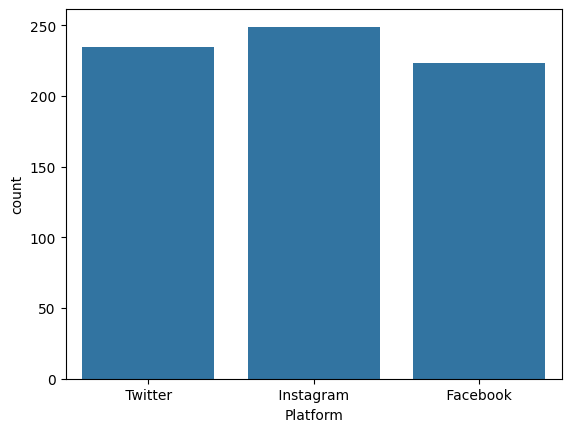

Platform
Instagram     249
Twitter       235
Facebook      223
Name: count, dtype: int64


In [254]:
#Checking for Imbalance by checking the amount of text in each platform.
sns.countplot(x=df_cleaned['Platform'])
plt.show()
print(df_cleaned['Platform'].value_counts())

Word Cloud

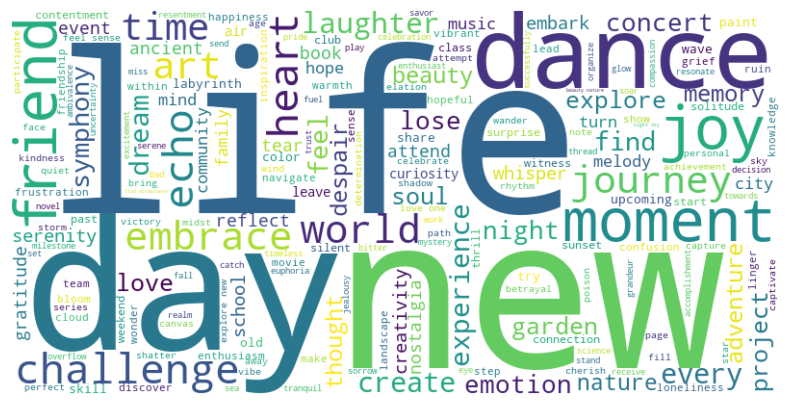

In [255]:
# Combining all text data into one large string
text_data = " ".join(df_cleaned['Lemmatized_Text'].dropna())  # Drop NaN values if any

# Generating the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axis
plt.show()